In [2]:
from collections import Counter
from itertools import combinations


import torch
import tqdm
import altair as alt
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from natsort import natsorted
import logomaker

from netam import framework
from dnsmex import dxsm_data, dnsm_zoo, dasm_zoo
from dnsmex.dasm_oe import write_sites_oe, OEPlotter
from dnsmex.local import localify


from netam.common import heavy_chain_shim
from netam.framework import load_crepe, load_pcp_df
from netam.sequences import translate_sequence, AA_STR_SORTED

from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify
from dnsmex.dxsm_data import pcp_df_of_nickname

figures_dir = localify("FIGURES_DIR")

In [3]:
from Bio import SeqIO
import pandas as pd

# Read FASTA and convert to DataFrame
records = []
for record in SeqIO.parse("/home/nharel/re/dasm-epistasis-experiments/ogrdb_human_IGH_20240627.fasta", "fasta"):
    records.append({
        'id': record.id,
        'sequence': str(record.seq),
        'length': len(record.seq)
    })

df = pd.DataFrame(records)
print(df.head())

            id              sequence  length
0   IGHD1-1*01     GGTACAACTGGAACGAC      17
1  IGHD1-14*01     GGTATAACCGGAACCAC      17
2  IGHD1-20*01     GGTATAACTGGAACGAC      17
3  IGHD1-26*01  GGTATAGTGGGAGCTACTAC      20
4   IGHD1-7*01     GGTATAACTGGAACTAC      17


In [4]:
df = df[df.id.str.startswith('IGHV')]
df.rename(columns={'id':'v_gene'}, inplace=True)
df['v_family'] = df['v_gene'].str.split('-').str[0]


In [5]:
## since this is nucleotides, make sure that the gaps are of a codon and not nucleotide per codon so that we can translate easily to amino acids. They are
for seq in df.sequence.tolist():
    counts = Counter([i // 3 for i in  range(len(seq)) if seq[i] == '.'])
    print([i == 3 for i in counts.values()])
    #print(counts)
    


[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, T

In [6]:
codons_df = []
for row in df.itertuples():
    sequence = row[2]
    seq_df = pd.DataFrame(list(enumerate([sequence[i:i+3] for i in range(0, len(sequence), 3)], start=1)), columns=['site', 'codon'])
    seq_df['v_gene'] = row[1]
    seq_df['v_family'] = row[4]
    codons_df.append(seq_df)

codons_df = pd.concat(codons_df, ignore_index=True)
codons_df = codons_df[(codons_df['codon'] != '...') & (codons_df['codon'].str.len() == 3)]  # Filter to ensure codons are of length 3 and remove gaps

# remove v genes that have stop codons in them - likely psuedogenes??
codons_df = codons_df[~codons_df.v_gene.isin(codons_df[codons_df['codon'].isin(['TGA', 'TAG'])].v_gene.unique().tolist())]

codons_df['amino_acid'] = codons_df['codon'].apply(translate_sequence)


In [7]:
codons_df

,site,codon,v_gene,v_family,amino_acid
0,1,CAG,IGHV1-18*01,IGHV1,Q
1,2,GTT,IGHV1-18*01,IGHV1,V
2,3,CAG,IGHV1-18*01,IGHV1,Q
3,4,CTG,IGHV1-18*01,IGHV1,L
4,5,GTG,IGHV1-18*01,IGHV1,V
...,...,...,...,...,...
21203,102,TTT,IGHV8-51-1*05,IGHV8,F
21204,103,AAC,IGHV8-51-1*05,IGHV8,N
21205,104,TGT,IGHV8-51-1*05,IGHV8,C
21206,105,GCA,IGHV8-51-1*05,IGHV8,A


In [8]:
# Calculate codon-level similarity between v_genes
def calculate_codon_similarity(df):
    """Calculate pairwise codon similarity between v_genes"""
    
    # Pivot to get v_genes as rows and positions as columns with codons as values
    codon_matrix = df.pivot(index='v_gene', columns='site', values='codon')
    
    # Fill NaN with a placeholder (e.g., 'NNN' for missing codons)
    codon_matrix = codon_matrix.fillna('NNN')
    
    # Calculate similarity matrix
    similarity_matrix = pd.DataFrame(index=codon_matrix.index, columns=codon_matrix.index, dtype=float)
    
    for gene1, gene2 in combinations(codon_matrix.index, 2):
        # Count identical codons
        identical_codons = (codon_matrix.loc[gene1] == codon_matrix.loc[gene2]).sum()
        total_positions = len(codon_matrix.columns)
        similarity = identical_codons / total_positions
        
        similarity_matrix.loc[gene1, gene2] = similarity
        similarity_matrix.loc[gene2, gene1] = similarity
    
    # Fill diagonal with 1.0 (self-similarity)
    np.fill_diagonal(similarity_matrix.values, 1.0)
    
    return similarity_matrix

# Calculate amino acid-level similarity between v_genes
def calculate_aa_similarity(df):
    """Calculate pairwise amino acid similarity between v_genes"""
    
    # Genetic code dictionary
    genetic_code = {
        'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
        'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
        'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
        'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',
        'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
        'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
        'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
        'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
        'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
        'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
        'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
        'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
        'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
        'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
        'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
        'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
    }
    
    # Convert codons to amino acids
    df_aa = df.copy()
    df_aa['amino_acid'] = df_aa['codon'].map(genetic_code).fillna('X')  # X for unknown
    
    # Pivot to get v_genes as rows and positions as columns with amino acids as values
    aa_matrix = df_aa.pivot(index='v_gene', columns='site', values='amino_acid')
    aa_matrix = aa_matrix.fillna('X')
    
    # Calculate similarity matrix
    similarity_matrix = pd.DataFrame(index=aa_matrix.index, columns=aa_matrix.index, dtype=float)
    
    for gene1, gene2 in combinations(aa_matrix.index, 2):
        # Count identical amino acids
        identical_aa = (aa_matrix.loc[gene1] == aa_matrix.loc[gene2]).sum()
        total_positions = len(aa_matrix.columns)
        similarity = identical_aa / total_positions
        
        similarity_matrix.loc[gene1, gene2] = similarity
        similarity_matrix.loc[gene2, gene1] = similarity
    
    # Fill diagonal with 1.0 (self-similarity)
    np.fill_diagonal(similarity_matrix.values, 1.0)
    
    return similarity_matrix

# Calculate both similarity matrices
print("Calculating codon-level similarity...")
codon_similarity = calculate_codon_similarity(codons_df)

print("Calculating amino acid-level similarity...")
aa_similarity = calculate_aa_similarity(codons_df)

# Display results
print("\nCodon-level similarity matrix:")
print(codon_similarity)

print("\nAmino acid-level similarity matrix:")
print(aa_similarity)

Calculating codon-level similarity...
Calculating amino acid-level similarity...

Codon-level similarity matrix:
v_gene         IGHV1-18*01  IGHV1-18*03  IGHV1-18*04  IGHV1-2*02  IGHV1-2*04  \
v_gene                                                                         
IGHV1-18*01       1.000000     0.990291     0.990291    0.796117    0.796117   
IGHV1-18*03       0.990291     1.000000     0.980583    0.786408    0.786408   
IGHV1-18*04       0.990291     0.980583     1.000000    0.805825    0.805825   
IGHV1-2*02        0.796117     0.786408     0.805825    1.000000    0.990291   
IGHV1-2*04        0.796117     0.786408     0.805825    0.990291    1.000000   
...                    ...          ...          ...         ...         ...   
IGHV7-4-1*05      0.553398     0.553398     0.543689    0.592233    0.592233   
IGHV7-81*01       0.592233     0.601942     0.582524    0.582524    0.582524   
IGHV8-51-1*02     0.262136     0.271845     0.252427    0.262136    0.262136   
IGHV8-5

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1500x1000 with 0 Axes>

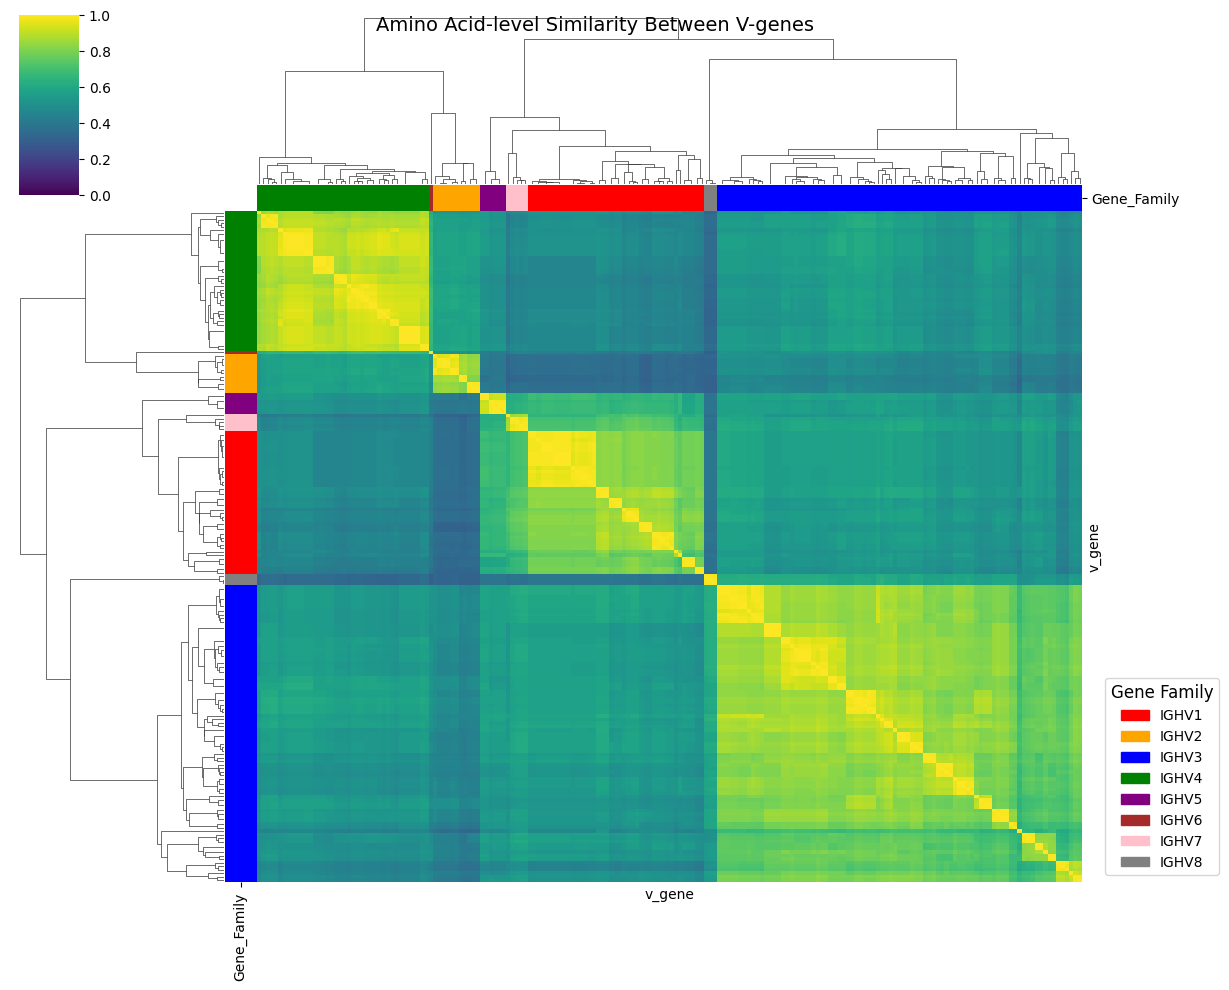

Gene family color mapping:
IGHV1: red
IGHV2: orange
IGHV3: blue
IGHV4: green
IGHV5: purple
IGHV6: brown
IGHV7: pink
IGHV8: gray


In [9]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create gene family dictionary
gene_family_dict = {i[1]: i[2] for i in list(codons_df[['v_gene', 'v_family']].drop_duplicates().itertuples())}

# Clean the gene names (remove allele info like *01, *02, etc.)
gene_family_dict_clean = {}
for gene, family in gene_family_dict.items():
  clean_gene = gene.split('*')[0]
  gene_family_dict_clean[clean_gene] = family

# Get unique categories and assign named colors
unique_cats = list(set(gene_family_dict_clean.values()))
named_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
category_colors_named = dict(zip(unique_cats, named_colors[:len(unique_cats)]))

# Apply same cleaning to index and map to colors
clean_index = [gene.split('*')[0] for gene in aa_similarity.index]
clean_columns = [gene.split('*')[0] for gene in aa_similarity.columns]

# Create row_colors and col_colors as DataFrames with proper index
row_colors_df = pd.DataFrame({
  'Gene_Family': pd.Series(clean_index, index=aa_similarity.index).map(gene_family_dict_clean).map(category_colors_named)
})

col_colors_df = pd.DataFrame({
  'Gene_Family': pd.Series(clean_columns, index=aa_similarity.columns).map(gene_family_dict_clean).map(category_colors_named)
})

# Create the clustermap with more space for legend
plt.figure(figsize=(15, 10))  # Make figure wider
g = sns.clustermap(aa_similarity, 
                 cmap='viridis', 
                 square=True, 
                 xticklabels=False,
                 yticklabels=False,
                 row_colors=row_colors_df,
                 col_colors=col_colors_df,
                 figsize=(12, 10),
                 vmin=0, vmax=1)  # Set maximum value for color scale

# Add title
g.fig.suptitle('Amino Acid-level Similarity Between V-genes', fontsize=14, y=0.98)

# Add legend for gene family colors - positioned in bottom right corner
legend_patches = [mpatches.Patch(color=color, label=family) 
               for family, color in sorted(category_colors_named.items())]

# Position the legend in the bottom right, outside the heatmap
g.ax_heatmap.legend(handles=legend_patches, 
                  bbox_to_anchor=(1.02, 0), 
                  loc='lower left',
                  title='Gene Family',
                  title_fontsize=12,
                  fontsize=10)

plt.show()

# Print the color mapping
print("Gene family color mapping:")
for family, color in sorted(category_colors_named.items()):
  print(f"{family}: {color}")

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1500x1000 with 0 Axes>

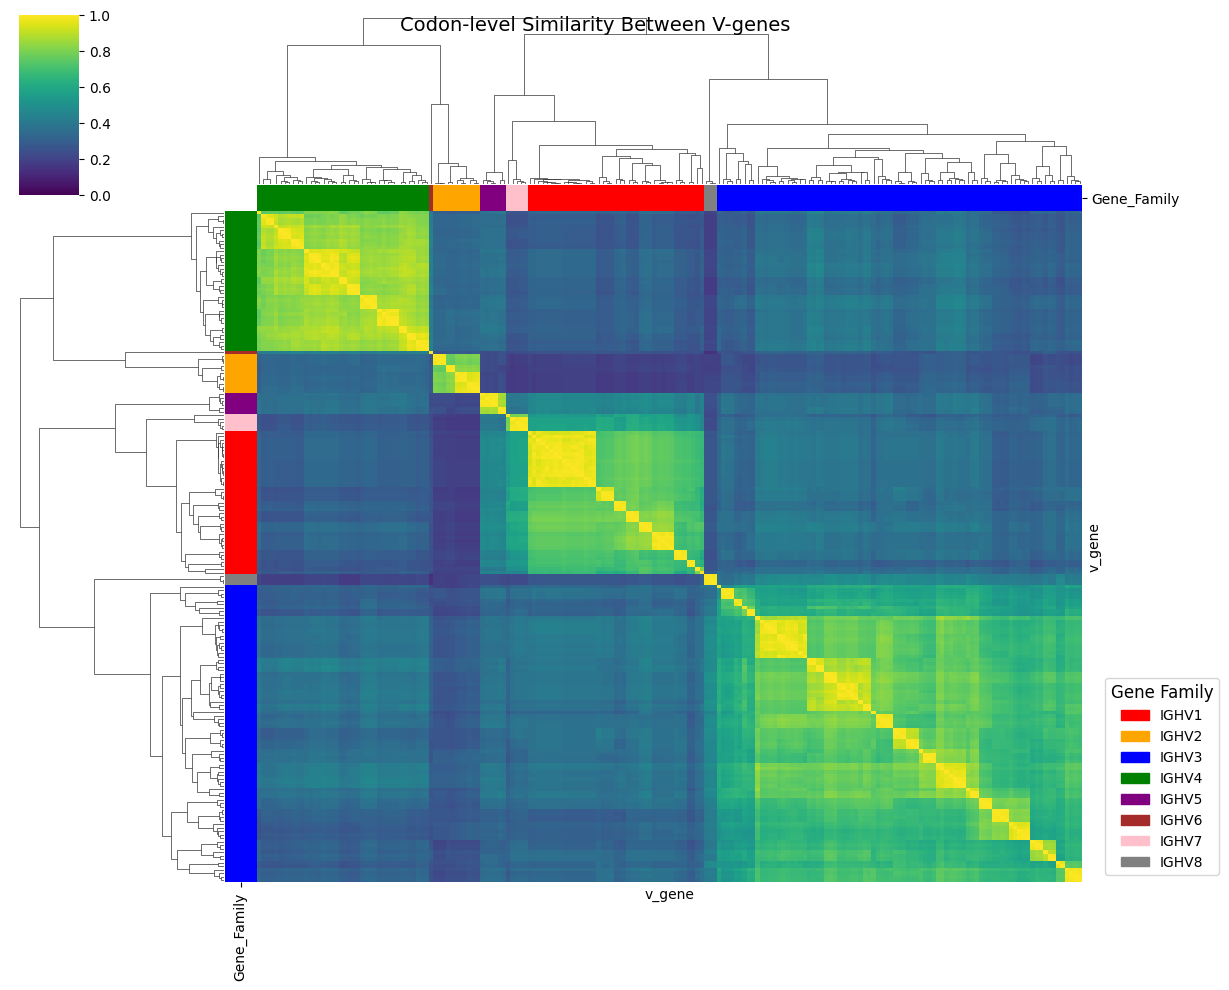

Gene family color mapping:
IGHV1: red
IGHV2: orange
IGHV3: blue
IGHV4: green
IGHV5: purple
IGHV6: brown
IGHV7: pink
IGHV8: gray


In [10]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create gene family dictionary
gene_family_dict = {i[1]: i[2] for i in list(codons_df[['v_gene', 'v_family']].drop_duplicates().itertuples())}

# Clean the gene names (remove allele info like *01, *02, etc.)
gene_family_dict_clean = {}
for gene, family in gene_family_dict.items():
 clean_gene = gene.split('*')[0]
 gene_family_dict_clean[clean_gene] = family

# Get unique categories and assign named colors
unique_cats = list(set(gene_family_dict_clean.values()))
named_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
category_colors_named = dict(zip(unique_cats, named_colors[:len(unique_cats)]))

# Apply same cleaning to index and map to colors for codon_similarity
clean_index = [gene.split('*')[0] for gene in codon_similarity.index]
clean_columns = [gene.split('*')[0] for gene in codon_similarity.columns]

# Create row_colors and col_colors as DataFrames with proper index
row_colors_df = pd.DataFrame({
 'Gene_Family': pd.Series(clean_index, index=codon_similarity.index).map(gene_family_dict_clean).map(category_colors_named)
})

col_colors_df = pd.DataFrame({
 'Gene_Family': pd.Series(clean_columns, index=codon_similarity.columns).map(gene_family_dict_clean).map(category_colors_named)
})

# Create the clustermap with more space for legend
plt.figure(figsize=(15, 10))  # Make figure wider
g = sns.clustermap(codon_similarity, 
                cmap='viridis', 
                square=True, 
                xticklabels=False,
                yticklabels=False,
                row_colors=row_colors_df,
                col_colors=col_colors_df,
                figsize=(12, 10),
                vmin=0, vmax=1)  # Set maximum value for color scale

# Add title
g.fig.suptitle('Codon-level Similarity Between V-genes', fontsize=14, y=0.98)

# Add legend for gene family colors - positioned in bottom right corner
legend_patches = [mpatches.Patch(color=color, label=family) 
              for family, color in sorted(category_colors_named.items())]

# Position the legend in the bottom right, outside the heatmap
g.ax_heatmap.legend(handles=legend_patches, 
                 bbox_to_anchor=(1.02, 0), 
                 loc='lower left',
                 title='Gene Family',
                 title_fontsize=12,
                 fontsize=10)

plt.show()

# Print the color mapping
print("Gene family color mapping:")
for family, color in sorted(category_colors_named.items()):
 print(f"{family}: {color}")

In [11]:
#### next - do DNSM/DASM comparisons only when the germline as the current codon in the dataframe
codons_df.to_csv(localify(f"DATA_DIR/germline_codons.csv"), index=False)

codon_similarity.to_csv(localify(f"DATA_DIR/germline_codon_similarity.csv"), index=True)
aa_similarity.to_csv(localify(f"DATA_DIR/germline_aa_similarity.csv"), index=True)

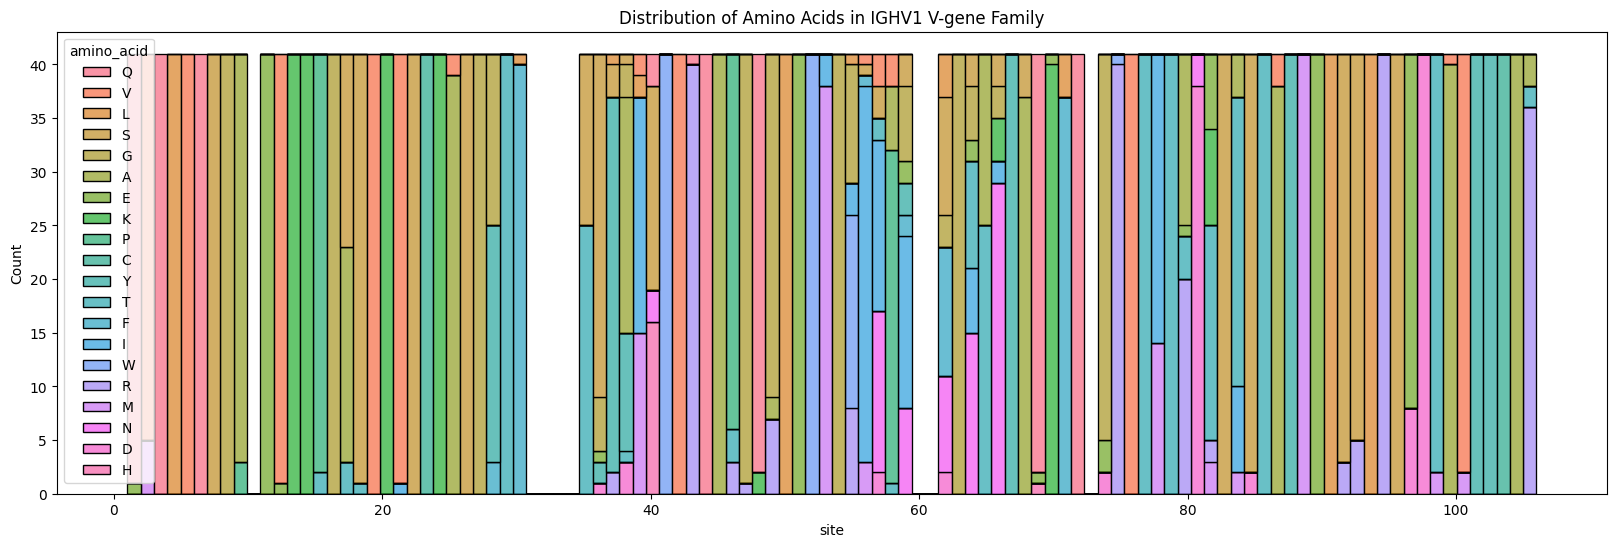

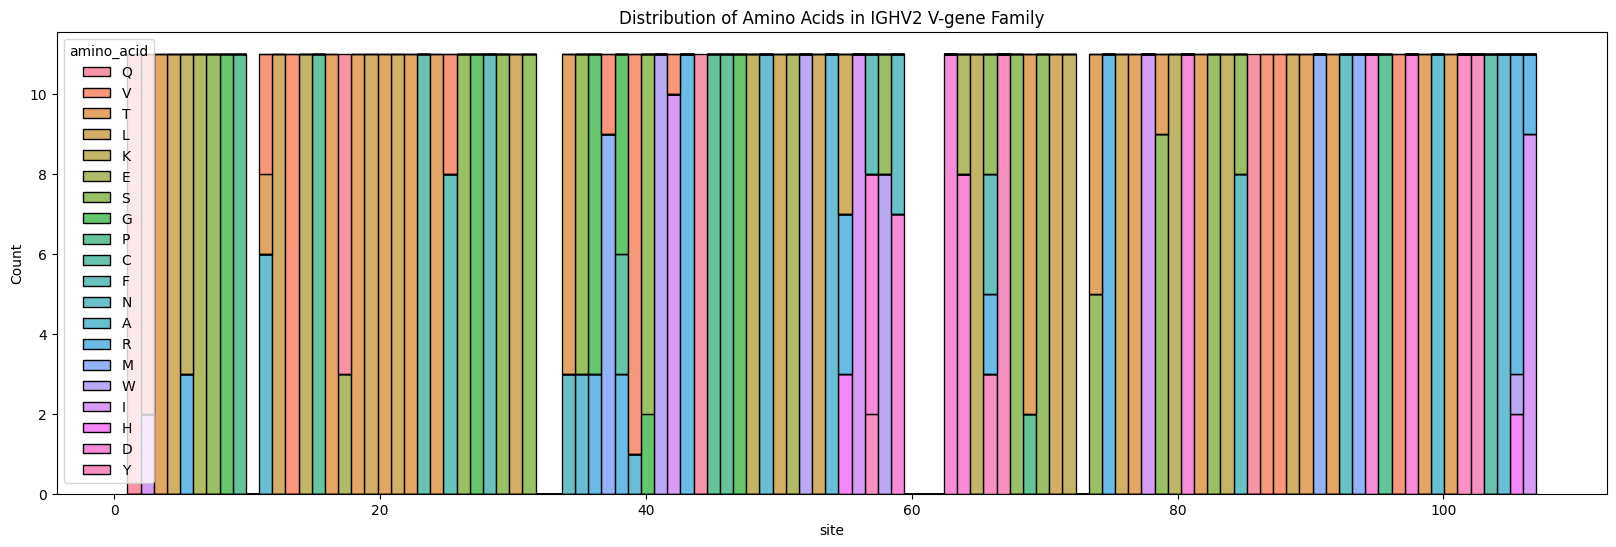

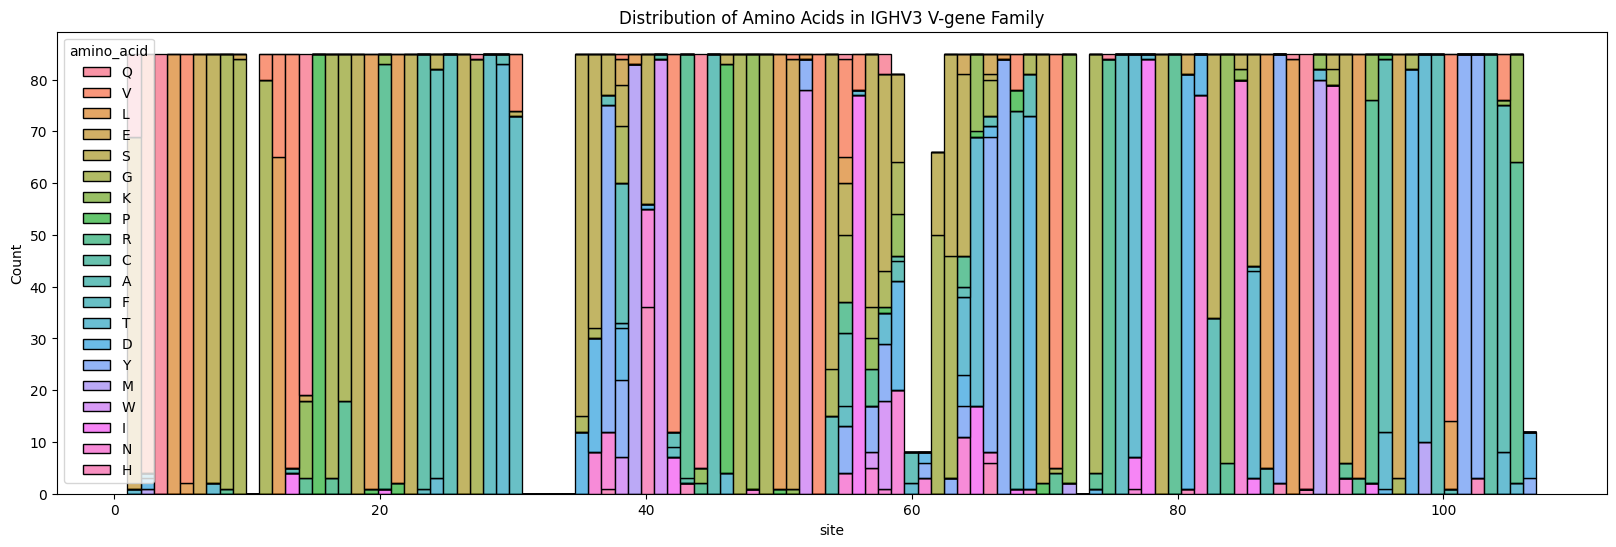

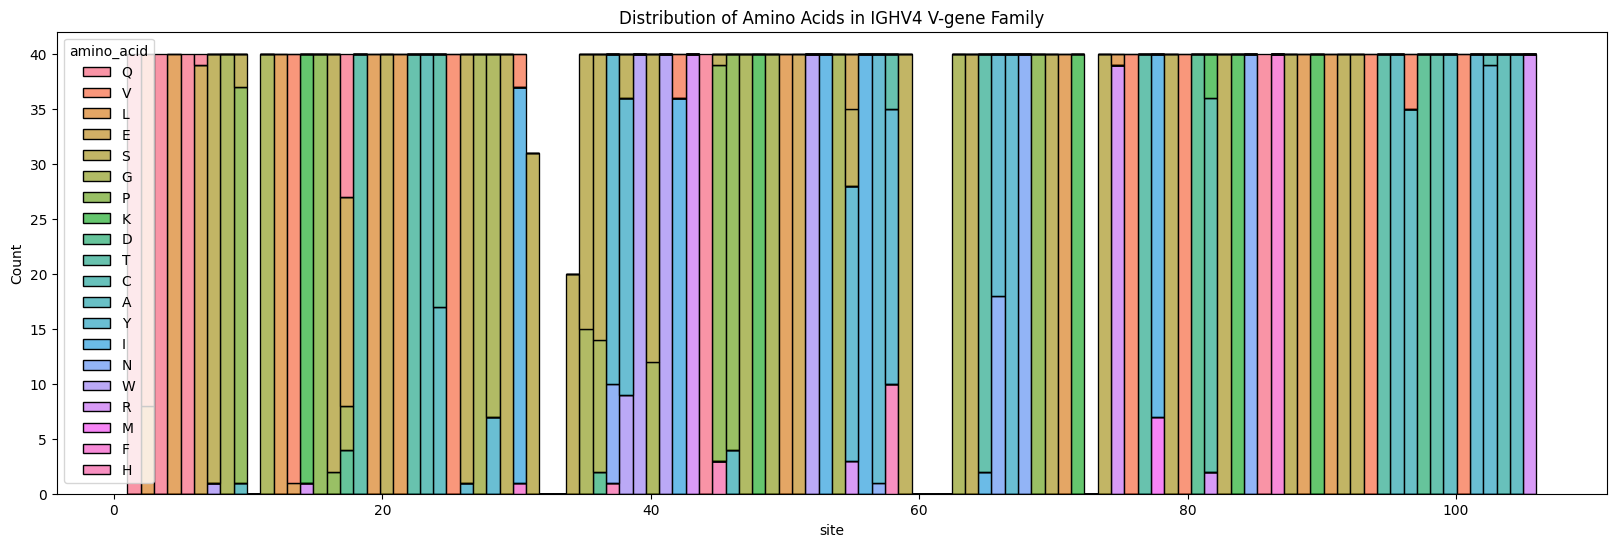

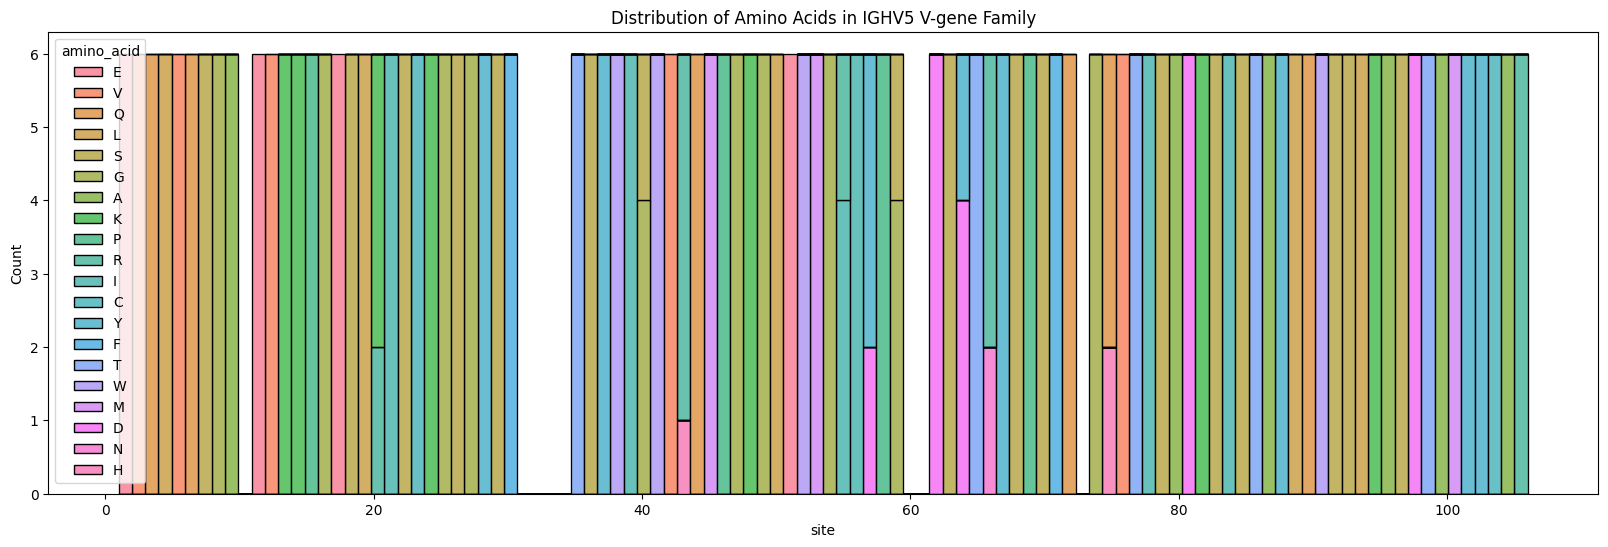

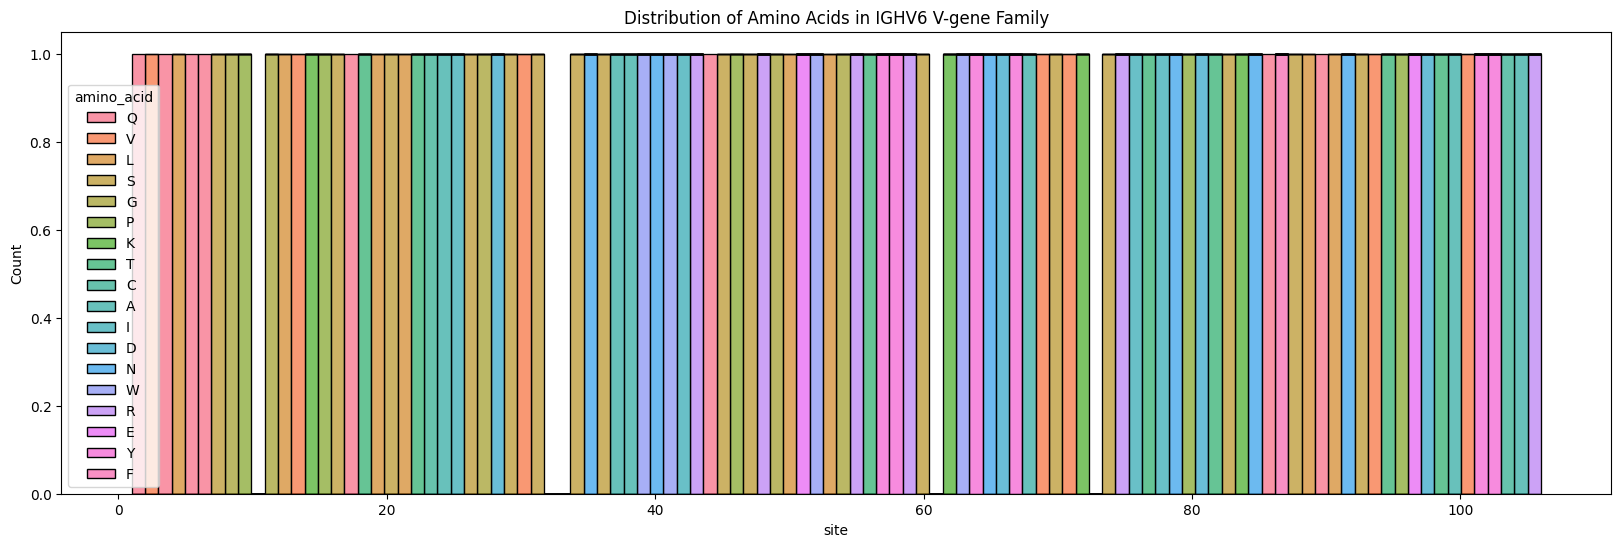

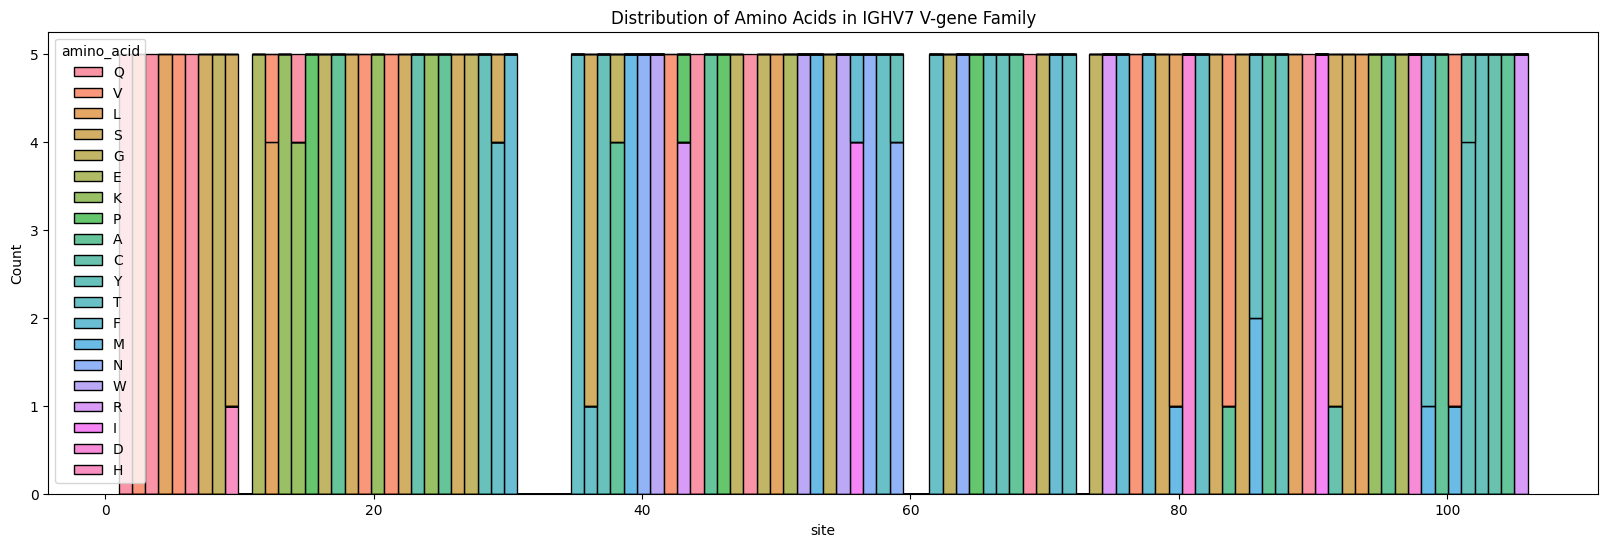

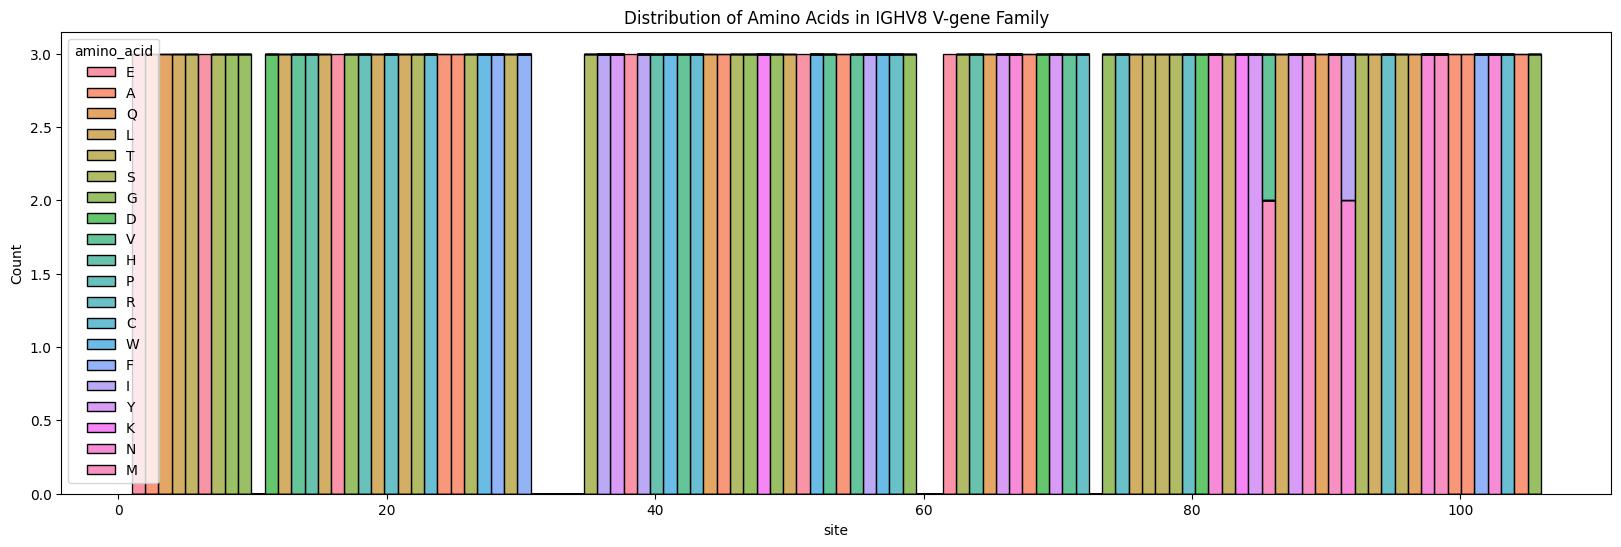

In [11]:
for i in codons_df.v_family.unique().tolist():
    fig, ax = plt.subplots(figsize=(20, 6))
    sns.histplot(codons_df[codons_df.v_family == i], x='site', hue='amino_acid', ax=ax, bins=codons_df[codons_df.v_family == i].site.max(), multiple="stack")
    #sns.histplot(codons_df[codons_df.v_family == i], x='site', hue='amino_acid', ax=ax, bins=len(codons_df[codons_df.v_family == i].site.drop_duplicates()), multiple="stack")

    ax.set_title(f"Distribution of Amino Acids in {i} V-gene Family")


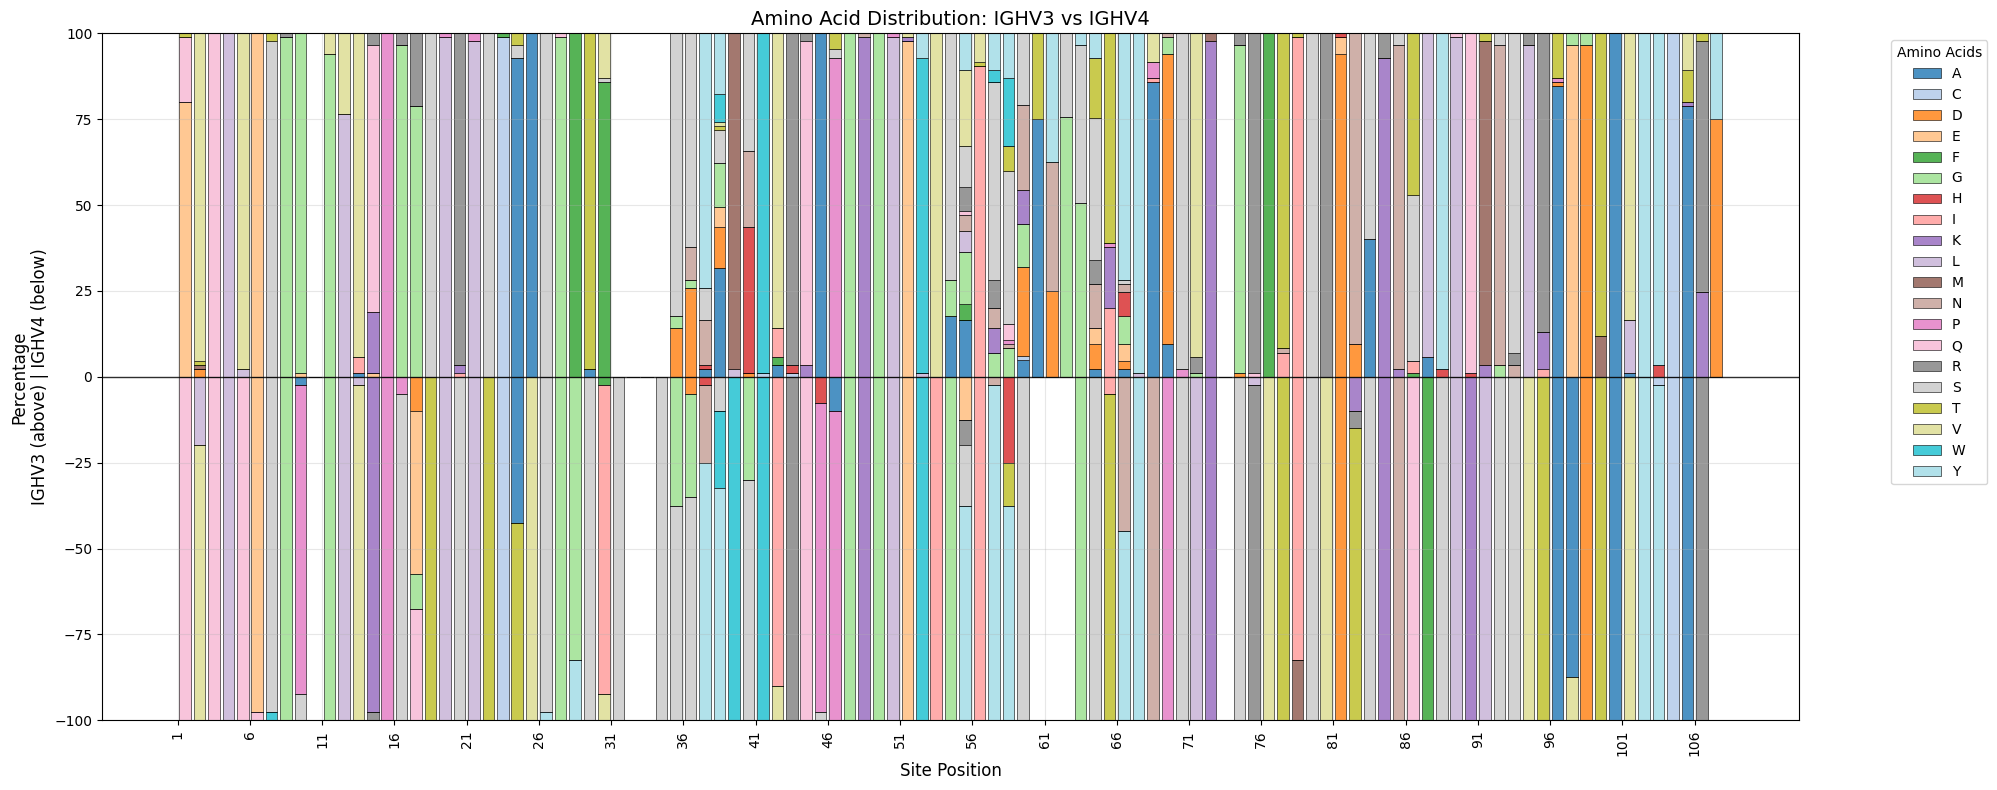

In [18]:
def plot_mirrored_vfamily_distribution(codons_df, v_family1, v_family2, figsize=(20, 8)):
    """
    Create a mirrored histogram showing amino acid distribution for two V families.
    v_family1 bars go above x-axis, v_family2 bars go below x-axis.
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Filter data for each family
    family1_data = codons_df[codons_df.v_family == v_family1].copy()
    family2_data = codons_df[codons_df.v_family == v_family2].copy()
    
    # Get common site range
    min_site = min(family1_data.site.min(), family2_data.site.min())
    max_site = max(family1_data.site.max(), family2_data.site.max())
    bins = range(min_site, max_site + 2)
    
    # Get all unique amino acids from both families
    all_amino_acids = sorted(set(family1_data['amino_acid'].unique()) | 
                           set(family2_data['amino_acid'].unique()))
    
    # Use tab20 colormap - specifically designed for 20 distinguishable colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_amino_acids)))
    color_map = dict(zip(all_amino_acids, colors))
    
    # Calculate percentages for family1 (above x-axis)
    family1_counts = {}
    family1_totals = np.zeros(len(bins)-1, dtype=float)
    
    for aa in all_amino_acids:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        if len(aa_data) > 0:
            hist, bin_edges = np.histogram(aa_data['site'], bins=bins)
            family1_counts[aa] = hist.astype(float)
        else:
            family1_counts[aa] = np.zeros(len(bins)-1, dtype=float)
        family1_totals += family1_counts[aa]
    
    # Convert to percentages
    for aa in all_amino_acids:
        family1_counts[aa] = np.divide(family1_counts[aa], family1_totals, 
                                     out=np.zeros_like(family1_counts[aa], dtype=float), 
                                     where=family1_totals!=0) * 100
    
    # Calculate percentages for family2 (below x-axis)
    family2_counts = {}
    family2_totals = np.zeros(len(bins)-1, dtype=float)
    
    for aa in all_amino_acids:
        aa_data = family2_data[family2_data['amino_acid'] == aa]
        if len(aa_data) > 0:
            hist, bin_edges = np.histogram(aa_data['site'], bins=bins)
            family2_counts[aa] = hist.astype(float)
        else:
            family2_counts[aa] = np.zeros(len(bins)-1, dtype=float)
        family2_totals += family2_counts[aa]
    
    # Convert to percentages and make negative
    for aa in all_amino_acids:
        family2_counts[aa] = -np.divide(family2_counts[aa], family2_totals, 
                                      out=np.zeros_like(family2_counts[aa], dtype=float), 
                                      where=family2_totals!=0) * 100
    
    # Plot both families with consistent styling
    bin_centers = [(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)]
    
    # Plot family1 above x-axis (positive values) - stack them
    bottom1 = np.zeros(len(bins)-1)
    for aa in all_amino_acids:
        if np.any(family1_counts[aa] > 0):
            ax.bar(bin_centers, family1_counts[aa], bottom=bottom1, 
                  color=color_map[aa], alpha=0.8, width=0.8, 
                  edgecolor='black', linewidth=0.5)
            bottom1 += family1_counts[aa]
    
    # Plot family2 below x-axis (negative values) - stack them
    bottom2 = np.zeros(len(bins)-1)
    for aa in all_amino_acids:
        if np.any(family2_counts[aa] < 0):
            ax.bar(bin_centers, family2_counts[aa], bottom=bottom2, 
                  color=color_map[aa], alpha=0.8, width=0.8, 
                  edgecolor='black', linewidth=0.5)
            bottom2 += family2_counts[aa]
    
    # Customize the plot
    ax.set_xlabel('Site Position', fontsize=12)
    ax.set_ylabel(f'Percentage\n{v_family1} (above) | {v_family2} (below)', fontsize=12)
    ax.set_title(f'Amino Acid Distribution: {v_family1} vs {v_family2}', fontsize=14)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis ticks every 5 positions
    ax.set_xticks(range(min_site, max_site + 1, 5))
    plt.xticks(rotation=90)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_map[aa], 
                                          edgecolor='black', linewidth=0.5, alpha=0.8))
        legend_labels.append(aa)
    
    ax.legend(legend_handles, legend_labels, bbox_to_anchor=(1.05, 1), loc='upper left', 
              title='Amino Acids')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

# Usage example:
# fig, ax = plot_mirrored_vfamily_distribution(codons_df, 'IGHV1', 'IGHV3')
fig, ax = plot_mirrored_vfamily_distribution(codons_df, 'IGHV3', 'IGHV4')

In [14]:
codon_similarity.loc['IGHV3-21*01', 'IGHV3-15*01']


np.float64(0.6310679611650486)

In [15]:
codon_similarity.loc['IGHV2-5*02', 'IGHV3-15*01']

np.float64(0.24271844660194175)

In [ ]:
codon_similarity.loc['IGHV4-59*01', 'IGHV4-34*01']

np.float64(0.8155339805825242)

In [17]:
0.81* 110

89.10000000000001

In [21]:
codons_df[codons_df.v_gene.isin(['IGHV4-59*01', 'IGHV4-34*01'])].groupby('v_gene').count()

,site,codon,v_family,amino_acid
v_gene,,,,
IGHV4-34*01,97,97,97,97
IGHV4-59*01,97,97,97,97


In [22]:
97*0.8155

79.1035